# Part 1: 전통적 Attribution 방법론 — Rule-based, Markov, Shapley

이 노트북에서는 가장 널리 사용되는 MTA 방법론의 원리를 설명하고, simulation ground truth 대비 정확도를 검증한다.

## 목차
1. Rule-based Attribution (5종)
2. Markov Chain Attribution
3. Shapley Value Attribution
4. 종합 비교

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json, sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 11})
sys.path.insert(0, os.path.abspath('../..'))

from part1_simulation import CHANNEL_NAMES, AttributionResult
from part1_simulation.config_loader import load_dgp_config
from part1_simulation.models.rule_based import (
    run_all_rule_based, compute_last_click, compute_first_click,
    compute_linear, compute_time_decay, compute_position_based,
)
from part1_simulation.models.markov import compute_markov_attribution, build_transition_matrix_order1, _build_sequences
from part1_simulation.models.shapley import compute_shapley_model_based, compute_shapley_conversion_rate
from part1_simulation.evaluation.evaluate import evaluate_all_methods, print_evaluation_summary
from part1_simulation.evaluation.metrics import compute_mae, compute_kendall_tau

journeys = pd.read_parquet("../../data/simulation/journeys.parquet")
with open("../../data/simulation/ground_truth.json") as f:
    gt = json.load(f)
gt_a = gt["ground_truth_A"]["channel_credits"]
config = load_dgp_config(overrides=["alpha_0=-5.625"])
print(f"Data loaded: {len(journeys):,} touchpoints, {journeys['user_id'].nunique():,} users")

Data loaded: 517,893 touchpoints, 100,000 users


## 1. Rule-based Attribution (5종)

Rule-based 방법론은 **사전 정의된 규칙**으로 크레딧을 배분한다. 학습이 없으므로 데이터 규모에 무관하게 일관된 결과를 산출하지만, 데이터의 구조를 반영하지 못한다.

예시 여정: `Display → Social → Organic → Paid Search → Email` (5 터치포인트, 전환)

| 방법론 | Display | Social | Organic | Paid Search | Email |
|--------|:------:|:------:|:------:|:-----------:|:-----:|
| **Last Click** | 0% | 0% | 0% | 0% | **100%** |
| **First Click** | **100%** | 0% | 0% | 0% | 0% |
| **Linear** | 20% | 20% | 20% | 20% | 20% |
| **Time Decay** | 5% | 8% | 13% | 22% | **52%** |
| **Position-Based** | **40%** | 7% | 7% | 7% | **40%** |

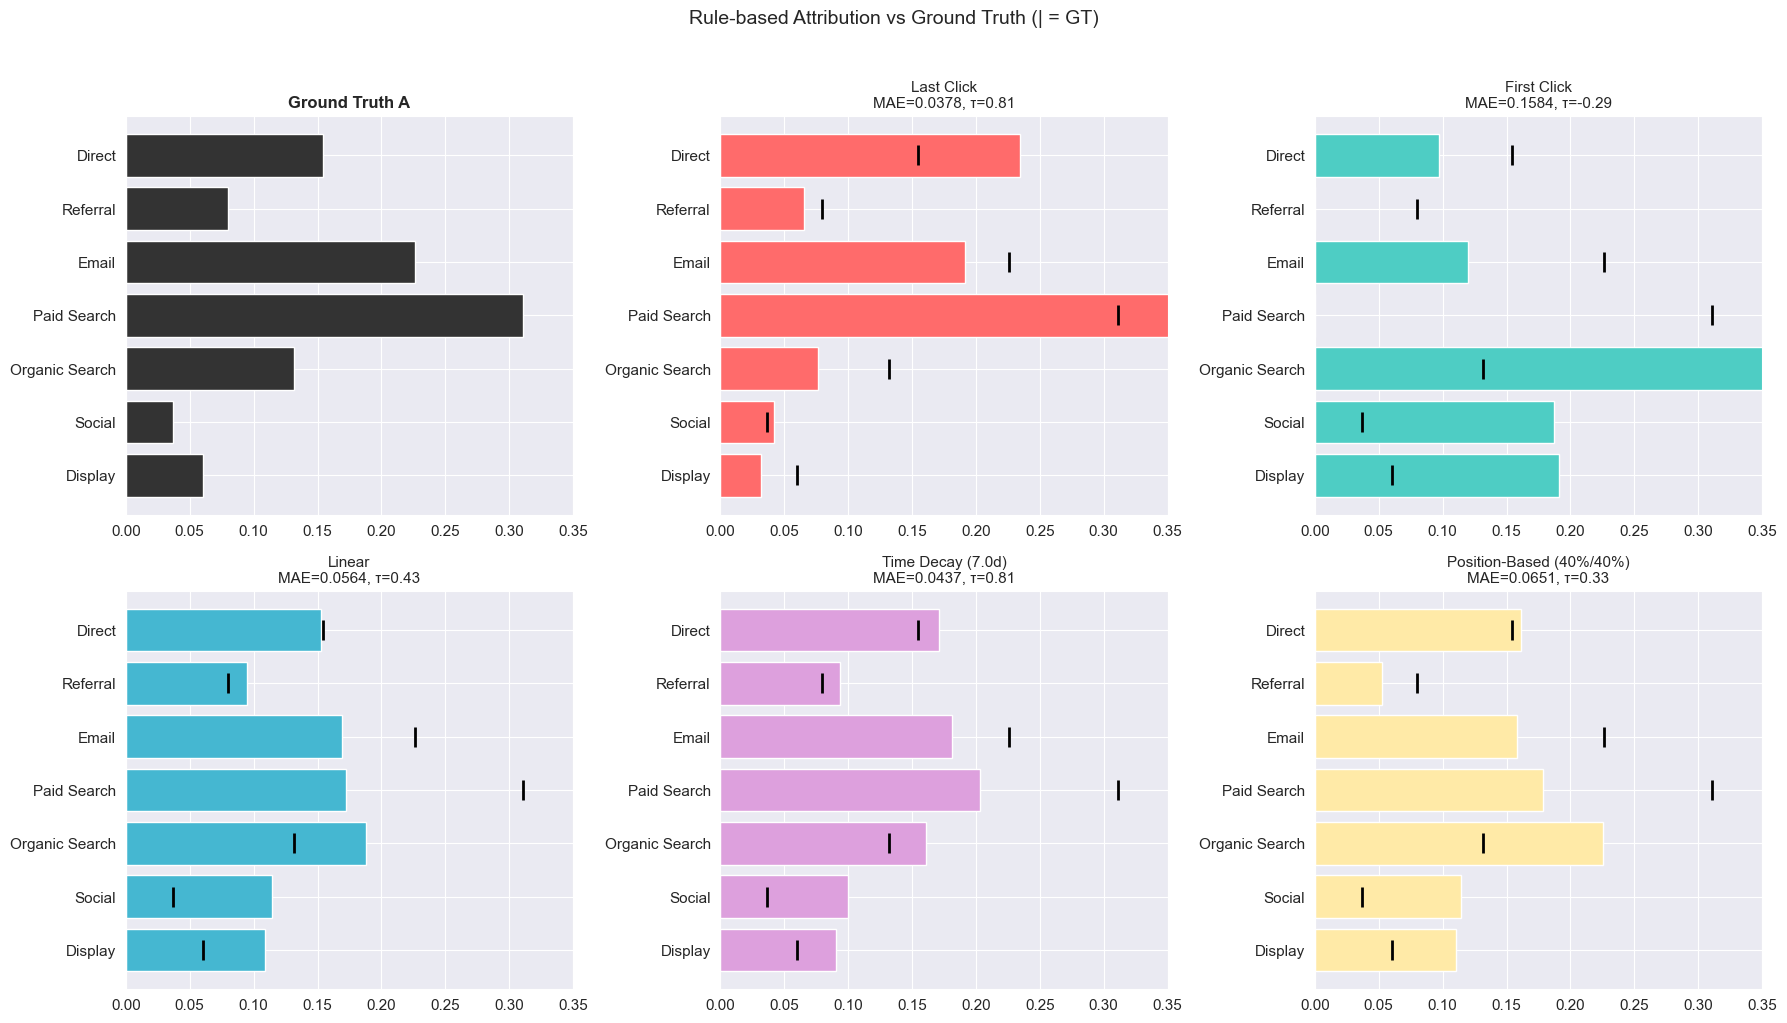

In [2]:
results = run_all_rule_based(journeys)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
channels = list(CHANNEL_NAMES)
gt_vals = [gt_a[c] for c in channels]

# Ground truth reference
axes[0].barh(channels, gt_vals, color="#333333", edgecolor="white")
axes[0].set_title("Ground Truth A", fontsize=12, fontweight="bold")
axes[0].set_xlim(0, 0.35)

colors = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#DDA0DD", "#FFEAA7"]
for i, (result, color) in enumerate(zip(results, colors)):
    vals = [result.channel_credits.get(c, 0) for c in channels]
    mae = compute_mae(result.channel_credits, gt_a)
    tau = compute_kendall_tau(result.channel_credits, gt_a)
    axes[i+1].barh(channels, vals, color=color, edgecolor="white")
    axes[i+1].set_title(f"{result.method}\nMAE={mae:.4f}, τ={tau:.2f}", fontsize=11)
    axes[i+1].set_xlim(0, 0.35)
    # GT reference line
    for j, gv in enumerate(gt_vals):
        axes[i+1].plot(gv, j, 'k|', markersize=15, markeredgewidth=2)

plt.suptitle("Rule-based Attribution vs Ground Truth (| = GT)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

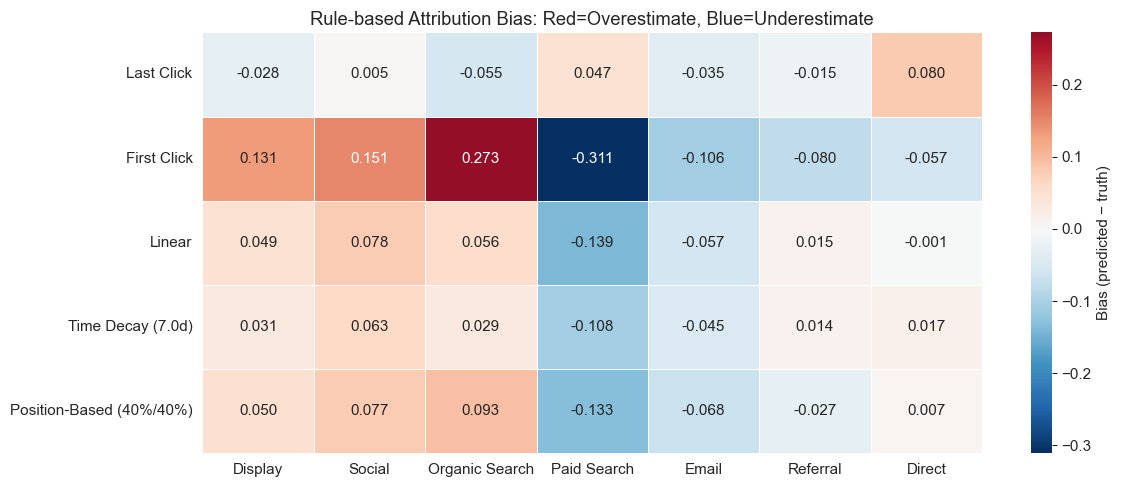

→ Last Click: Paid Search/Direct 과대평가 (+0.07~0.09), Display/Email 과소평가
→ First Click: Display 과대평가 (+0.12), Paid Search 과소평가 (-0.29) — 완전히 역전
→ Time Decay: 가장 균형적이나 Paid Search를 여전히 과소평가 (-0.08)


In [3]:
# Bias heatmap: method × channel
bias_data = {}
for result in results:
    bias_data[result.method] = {ch: result.channel_credits.get(ch, 0) - gt_a[ch] for ch in channels}
bias_df = pd.DataFrame(bias_data).T

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(bias_df, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax,
            linewidths=0.5, cbar_kws={"label": "Bias (predicted − truth)"})
ax.set_title("Rule-based Attribution Bias: Red=Overestimate, Blue=Underestimate")
plt.tight_layout()
plt.show()

print("→ Last Click: Paid Search/Direct 과대평가 (+0.07~0.09), Display/Email 과소평가")
print("→ First Click: Display 과대평가 (+0.12), Paid Search 과소평가 (-0.29) — 완전히 역전")
print("→ Time Decay: 가장 균형적이나 Paid Search를 여전히 과소평가 (-0.08)")

## 2. Markov Chain Attribution

Markov Chain은 채널 간 **전이 확률**을 데이터에서 추정하고, **Removal Effect**(채널 제거 시 전환 확률 변화)로 기여도를 산출한다.

상태 공간: 7채널 + Start + Conversion(흡수) + Null(흡수) = 10 상태

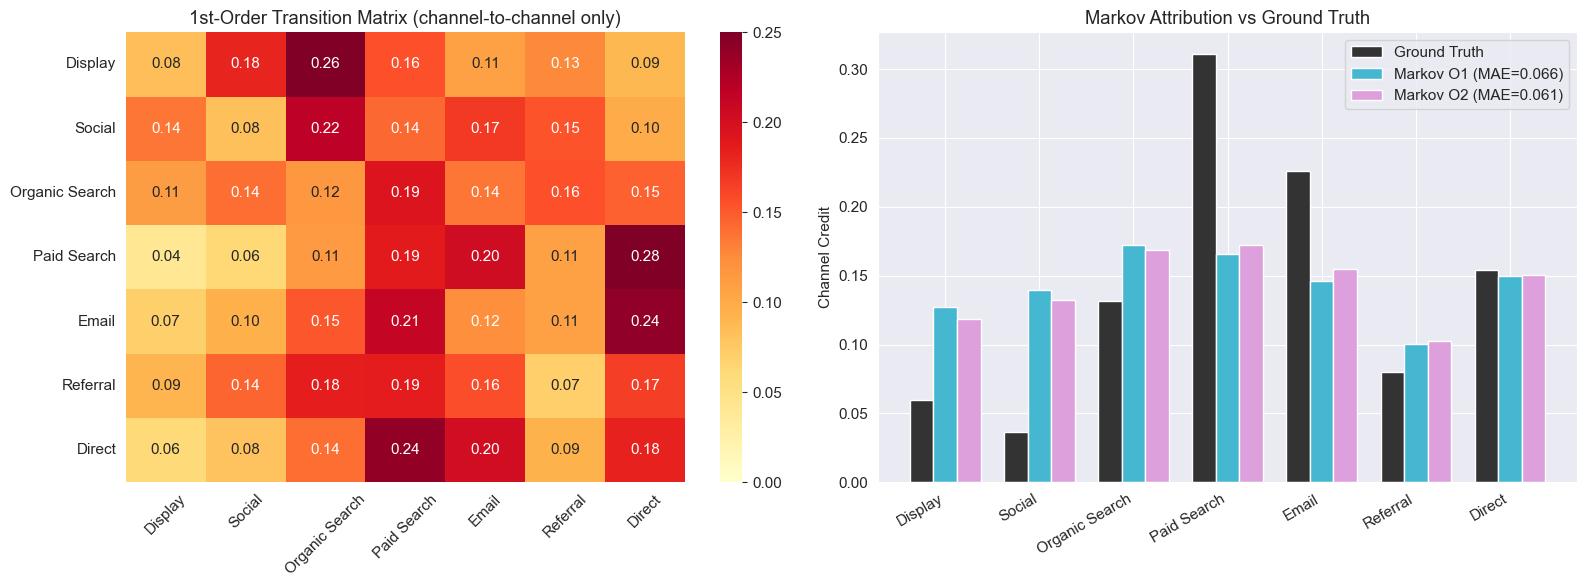

Base conversion prob (from chain): 0.0231
→ Markov는 채널 전이 구조를 반영하지만, temporal decay와 cross-influence를 직접 모델링하지 않아 한계가 있다.


In [4]:
# 1st-order 전이 행렬 시각화
sequences = _build_sequences(journeys)
matrix, states = build_transition_matrix_order1(sequences)

# 채널 간 전이만 추출 (Start/Conversion/Null 제외)
ch_indices = [states.index(ch) for ch in CHANNEL_NAMES]
ch_matrix = matrix[np.ix_(ch_indices, ch_indices)]
# Normalize rows
row_sums = ch_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
ch_matrix_norm = ch_matrix / row_sums

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(ch_matrix_norm, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=CHANNEL_NAMES, yticklabels=CHANNEL_NAMES, ax=ax1, vmin=0, vmax=0.25)
ax1.set_title("1st-Order Transition Matrix (channel-to-channel only)")
ax1.tick_params(axis='x', rotation=45)

# Markov attribution results
m1 = compute_markov_attribution(journeys, order=1)
m2 = compute_markov_attribution(journeys, order=2)

x = np.arange(len(channels))
width = 0.25
ax2.bar(x - width, gt_vals, width, label="Ground Truth", color="#333333")
ax2.bar(x, [m1.channel_credits[c] for c in channels], width, label=f"Markov O1 (MAE={compute_mae(m1.channel_credits, gt_a):.3f})", color="#45B7D1")
ax2.bar(x + width, [m2.channel_credits[c] for c in channels], width, label=f"Markov O2 (MAE={compute_mae(m2.channel_credits, gt_a):.3f})", color="#DDA0DD")
ax2.set_xticks(x)
ax2.set_xticklabels(channels, rotation=30, ha="right")
ax2.set_ylabel("Channel Credit")
ax2.set_title("Markov Attribution vs Ground Truth")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Base conversion prob (from chain): {m1.metadata['base_conversion_prob']:.4f}")
print(f"→ Markov는 채널 전이 구조를 반영하지만, temporal decay와 cross-influence를 직접 모델링하지 않아 한계가 있다.")

## 3. Shapley Value Attribution

Shapley Value는 **공정한 기여도 배분**을 위한 게임이론 접근:
- 가치 함수 v(S): 채널 집합 S의 "가치" (전환율 또는 모델 예측)
- Shapley value φᵢ: 모든 가능한 coalition에서 채널 i의 **한계 기여**의 가중 평균

7채널 = 2⁷ = 128 coalitions → 정확 계산 가능.

**두 가지 value function:**
- **Version A (conv. rate):** v(S) = 채널 집합 S만 포함하는 여정의 전환율
- **Version B (model-based):** 로지스틱 회귀 학습 후 non-S 채널 마스킹

Computing Shapley (model-based)... (128 coalitions)


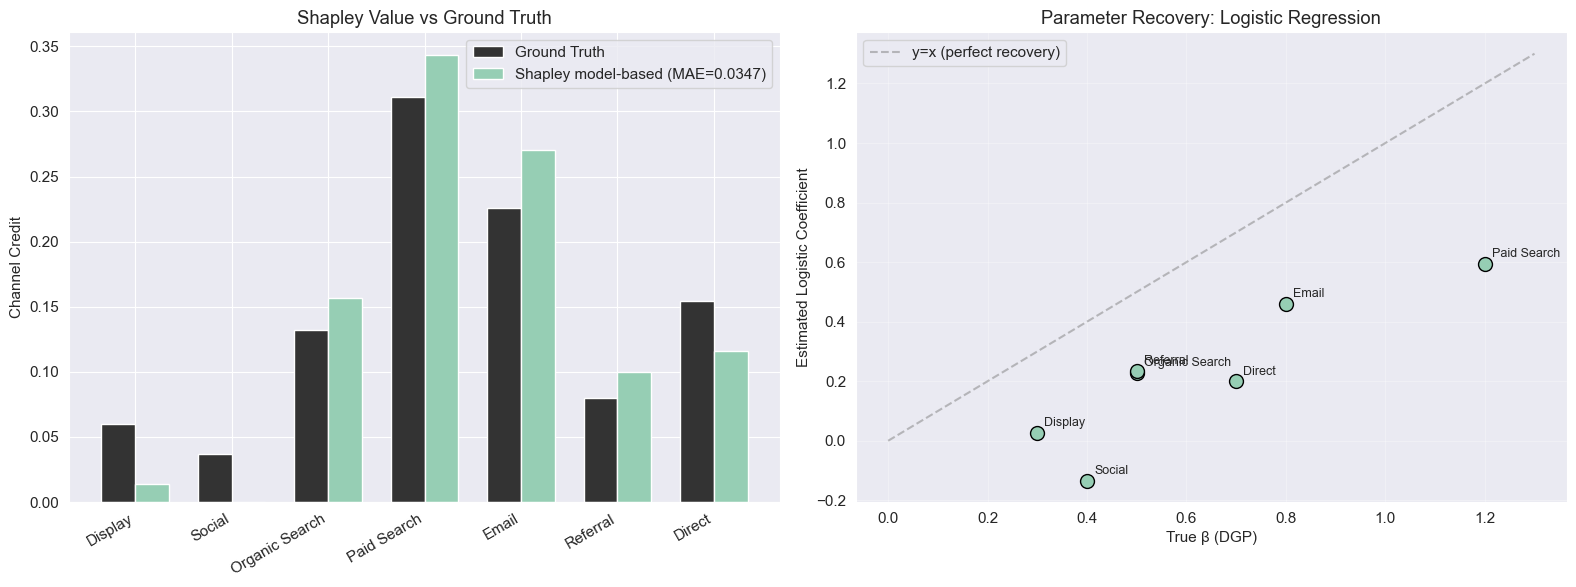


Shapley axiom check:
  Efficiency (sum of credits): 1.000000 (should be 1.0)
  Ranking (Kendall's Tau vs GT): 0.9048


In [5]:
print("Computing Shapley (model-based)... (128 coalitions)")
s_mb = compute_shapley_model_based(journeys)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Shapley credits vs GT
x = np.arange(len(channels))
width = 0.35
ax1.bar(x - width/2, gt_vals, width, label="Ground Truth", color="#333333")
ax1.bar(x + width/2, [s_mb.channel_credits[c] for c in channels], width,
        label=f"Shapley model-based (MAE={compute_mae(s_mb.channel_credits, gt_a):.4f})", color="#96CEB4")
ax1.set_xticks(x)
ax1.set_xticklabels(channels, rotation=30, ha="right")
ax1.set_ylabel("Channel Credit")
ax1.set_title("Shapley Value vs Ground Truth")
ax1.legend()

# Logistic coefficients vs true β
if "logistic_coefs" in s_mb.metadata:
    coefs = s_mb.metadata["logistic_coefs"]
    true_betas = gt["dgp_parameters"]["betas"]
    coef_vals = [coefs[c] for c in channels]
    beta_vals = [true_betas[c] for c in channels]

    ax2.scatter(beta_vals, coef_vals, s=100, c="#96CEB4", edgecolor="black", zorder=3)
    for c, bv, cv in zip(channels, beta_vals, coef_vals):
        ax2.annotate(c, (bv, cv), textcoords="offset points", xytext=(5, 5), fontsize=9)
    ax2.plot([0, 1.3], [0, 1.3], '--', color='gray', alpha=0.5, label="y=x (perfect recovery)")
    ax2.set_xlabel("True β (DGP)")
    ax2.set_ylabel("Estimated Logistic Coefficient")
    ax2.set_title("Parameter Recovery: Logistic Regression")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nShapley axiom check:")
print(f"  Efficiency (sum of credits): {sum(s_mb.channel_credits.values()):.6f} (should be 1.0)")
print(f"  Ranking (Kendall's Tau vs GT): {compute_kendall_tau(s_mb.channel_credits, gt_a):.4f}")

## 4. 종합 비교

In [6]:
# Load precomputed results for all traditional methods
all_eval = pd.read_csv("../../results/part1/all_methods_evaluation.csv")
traditional = all_eval[all_eval["method"].isin([
    "Last Click", "First Click", "Linear", "Time Decay (7.0d)", "Position-Based (40%/40%)",
    "Markov (order=1)", "Markov (order=2)", "Shapley (conv. rate)", "Shapley (model-based)",
])].sort_values("mae")

print("=== Traditional Methods Ranking (vs Ground Truth A) ===\n")
print(f"{'Method':<30s} {'MAE':>8s} {'Tau':>8s} {'Top-3':>8s}")
print("-" * 58)
for _, row in traditional.iterrows():
    print(f"{row['method']:<30s} {row['mae']:>8.4f} {row['kendall_tau']:>8.4f} {row['top3_accuracy']:>8.2f}")

print(f"\n→ Best: {traditional.iloc[0]['method']} (MAE={traditional.iloc[0]['mae']:.4f})")
print("→ Shapley (model-based)가 전통 방법론 중 가장 정확: coalition 기반 공정 배분 + 모델 smoothing")
print("→ Markov order-2 > order-1: 더 많은 시퀀스 정보가 도움")
print("→ First Click은 ground truth와 anti-correlated: 인지 채널에 100% 크레딧의 치명적 오류")

=== Traditional Methods Ranking (vs Ground Truth A) ===

Method                              MAE      Tau    Top-3
----------------------------------------------------------
Shapley (model-based)            0.0347   0.9048     0.67
Last Click                       0.0378   0.8095     1.00
Time Decay (7.0d)                0.0437   0.8095     1.00
Linear                           0.0564   0.4286     0.67
Markov (order=2)                 0.0610   0.5238     0.67
Position-Based (40%/40%)         0.0651   0.3333     0.67
Markov (order=1)                 0.0658   0.3333     0.67
First Click                      0.1584  -0.2928     0.00

→ Best: Shapley (model-based) (MAE=0.0347)
→ Shapley (model-based)가 전통 방법론 중 가장 정확: coalition 기반 공정 배분 + 모델 smoothing
→ Markov order-2 > order-1: 더 많은 시퀀스 정보가 도움
→ First Click은 ground truth와 anti-correlated: 인지 채널에 100% 크레딧의 치명적 오류


---
## 요약

| 방법론 | 장점 | 한계 | 추천 상황 |
|--------|------|------|----------|
| **Last Click** | 구현 간단, 직관적 | Lower-funnel 과대평가 | 빠른 baseline |
| **Time Decay** | Recency 반영, 안정적 | 최적 half-life 선택 필요 | 전환 직전 채널 중시 환경 |
| **Markov** | 전이 구조 반영 | Pairwise 상호작용 미포착 | 채널 시퀀스 패턴 분석 |
| **Shapley** | 공리적 공정성, 높은 정확도 | 채널 수 증가 시 계산 폭발 | ≤15 채널 환경 (정확 계산) |

다음 노트북: [03_deep_learning_attribution.ipynb](03_deep_learning_attribution.ipynb) — LSTM + Attention, Transformer